# Docker HDDM 参数拟合工作流

**项目**: GP-SPE 实验设计优化 — Self-Matching Task DDM 参数提取

---

## ⚠️ Docker 启动方式（重要）

在 CMD/PowerShell 中执行以下命令启动 Docker Jupyter：

```bash
docker pull hcp4715/hddm

docker run -it --rm --cpus=4 ^
  -v /d/GitHub_programe/GitHub/Guassion-Process-Experiment-Design:/home/jovyan/work ^
  -p 8888:8888 ^
  hcp4715/hddm ^
  jupyter notebook
```

> **注意**: 挂载路径是**项目根目录**（而非 Python_HDDM 子目录），这样数据直接写入正确的 `2_Data/` 和 `3_Figures/` 位置。

---

## 工作流步骤

| 步骤 | 环境 | 内容 |
|------|------|------|
| **Step 1** | **Docker（本文件）** | **数据预处理 → HDDM 就绪 CSV** |\n| **Step 2** | **Docker（本文件）** | **HDDM 层级模型 MCMC 拟合** |\n| Step 3 | Docker（本文件） | 迹线提取 + 参数可视化 |

---
## 环境检查

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

BASE_DIR = Path("/home/jovyan/work")
DATA_DIR = BASE_DIR / "2_Data" / "Real_Data" / "HDDM_Ready"
OUT_DIR  = BASE_DIR / "2_Data" / "Real_Data" / "HDDM_Traces"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR:  {BASE_DIR}  存在: {BASE_DIR.exists()}")
print(f"DATA_DIR:  {DATA_DIR}  存在: {DATA_DIR.exists()}")
print(f"OUT_DIR:   {OUT_DIR}")

try:
    import hddm
    print(f"HDDM 版本: {hddm.__version__}")
except ImportError:
    print("❌ HDDM 未安装！请在 Docker 容器 (hcp4715/hddm) 中运行此笔记本。")
    sys.exit(1)

csv_files = sorted(DATA_DIR.glob("hddm_data_group*.csv"))
if not csv_files:
    print(f"❌ 未找到 HDDM 就绪数据！请先运行 step1_prepare_data.py")
    print(f"   预期路径: {DATA_DIR}")
else:
    print(f"✅ 发现 {len(csv_files)} 个待拟合数据文件")
    for f in csv_files:
        df = pd.read_csv(f)
        n_subj = df["subj_idx"].nunique()
        n_omis = df["omission"].sum()
        print(f"   {f.name}: {n_subj}被试, {len(df)}试次, 遗漏{n_omis}")

BASE_DIR:  /home/jovyan/work  存在: True
DATA_DIR:  /home/jovyan/work/2_Data/Real_Data/HDDM_Ready  存在: True
OUT_DIR:   /home/jovyan/work/2_Data/Real_Data/HDDM_Traces
HDDM 版本: 1.0.1RC
✅ 发现 8 个待拟合数据文件
   hddm_data_group1_P0_T30_W300.csv: 11被试, 2860试次, 遗漏2068
   hddm_data_group2_P0_T30_W600.csv: 12被试, 3120试次, 遗漏1636
   hddm_data_group3_P120_T30_W600.csv: 10被试, 2600试次, 遗漏1004
   hddm_data_group4_P120_T80_W600.csv: 11被试, 2860试次, 遗漏1098
   hddm_data_group5_P8_T100_W1100.csv: 11被试, 2860试次, 遗漏313
   hddm_data_group6_P120_T500_W1500.csv: 10被试, 2600试次, 遗漏146
   hddm_data_group7_P120_T80_W800.csv: 12被试, 3120试次, 遗漏446
   hddm_data_group8_P120_T80_W800.csv: 11被试, 2860试次, 遗漏420


---
## Step 1: 数据预处理

从原始 CSV 中提取 Matching 试次、标记遗漏试次、输出 HDDM 就绪格式。

> ⚠️ 如果 `2_Data/Real_Data/HDDM_Ready/` 下已有 `hddm_data_group*.csv` 文件，可以跳过此步骤直接进入 Step 2。

In [ ]:
# Step 1: 数据预处理 - 准备 HDDM 输入数据
# 从 88 个原始 CSV 中提取 Matching 试次，输出 HDDM 就绪格式

RAW_DIR = BASE_DIR / "2_Data" / "Real_Data" / "UnExtact" / "raw"
READY_DIR = BASE_DIR / "2_Data" / "Real_Data" / "HDDM_Ready"
READY_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Step 1: 数据预处理 - 准备 HDDM 输入数据")
print("=" * 60)

csv_files = sorted(RAW_DIR.glob("EXP_data_group*.csv"))
print(f"\n发现 {len(csv_files)} 个原始数据文件")

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f"合并总行数: {len(df_all)}")

print("\n各组被试分布:")
group_subjects = df_all.groupby("groupID")["subjectID"].nunique()
for gid in sorted(group_subjects.index):
    print(f"  Group {gid}: {group_subjects[gid]} 名被试")

# 过滤 formal 阶段
df_f = df_all[df_all["stage"] == "formal"].copy()
print(f"\n过滤 stage='formal' 后: {len(df_f)} 行")

# 仅保留 Matching 试次: (circle,self) 或 (square,stranger)
matching_mask = (
    ((df_f["Shape"] == "circle") & (df_f["Label"] == "self"))
    | ((df_f["Shape"] == "square") & (df_f["Label"] == "stranger"))
)
df_match = df_f[matching_mask].copy()
print(f"过滤 Matching 试次后: {len(df_match)} 行")

# 构建 HDDM 所需列
df_match["identity"] = df_match["Label"].map({"self": 1, "stranger": 0})
df_match["RT_num"] = pd.to_numeric(df_match["RT"], errors="coerce")
df_match["omission"] = df_match["RT_num"].isna().astype(int)
df_match["T_s"] = pd.to_numeric(df_match["T"], errors="coerce")
df_match["W_s"] = pd.to_numeric(df_match["W"], errors="coerce")
df_match["deadline"] = df_match["T_s"] + df_match["W_s"]

# 遗漏试次 RT 设为截止时间 (T+W)，作为右截尾数据
df_match["rt"] = np.where(
    df_match["omission"] == 1,
    df_match["deadline"],
    df_match["RT_num"],
)

# response: 正确=1, 错误=0
df_match["response"] = np.where(df_match["Correct"] == 1, 1, 0)

print("\n各组 HDDM 就绪数据:")
for gid in sorted(df_match["groupID"].unique()):
    gdf = df_match[df_match["groupID"] == gid].copy()
    subj_map = {s: i for i, s in enumerate(sorted(gdf["subjectID"].unique()))}
    gdf["subj_idx"] = gdf["subjectID"].map(subj_map)

    hddm_cols = ["subj_idx", "rt", "response", "identity", "omission"]
    hddm_df = gdf[hddm_cols].copy()

    P_val = int(gdf["P"].iloc[0])
    T_val = int(gdf["T_s"].iloc[0] * 1000)
    W_val = int(gdf["W_s"].iloc[0] * 1000)

    fn = f"hddm_data_group{gid}_P{P_val}_T{T_val}_W{W_val}.csv"
    out_path = READY_DIR / fn
    hddm_df.to_csv(out_path, index=False)

    n_subj = gdf["subjectID"].nunique()
    n_trials = len(hddm_df)
    n_omissions = hddm_df["omission"].sum()
    omission_rate = n_omissions / n_trials * 100
    n_valid = (hddm_df["omission"] == 0).sum()
    acc = hddm_df.loc[hddm_df["omission"] == 0, "response"].mean()

    print(f"  Group {gid} (P={P_val}, T={T_val}ms, W={W_val}ms) → {fn}")
    print(f"    被试: {n_subj} | 试次: {n_trials}")
    print(f"    有效: {n_valid} | 遗漏: {n_omissions} ({omission_rate:.1f}%)")
    print(f"    正确率(有效试次): {acc:.3f}")

print(f"\n✅ HDDM 就绪数据已保存到: {READY_DIR}")

# 更新 csv_files 变量供后续 Step 2 使用
csv_files = sorted(READY_DIR.glob("hddm_data_group*.csv"))
print(f"\n准备拟合 {len(csv_files)} 个文件")

---
## Step 2: HDDM 层级模型拟合

对每组实验条件独立拟合层级 DDM，使用 `depends_on={"v": "identity"}` 区分 Self/Stranger 漂移率。

**预估时间**: 每组约 2-5 分钟，全部 8 组约 15-40 分钟。

In [2]:
# Step 2: HDDM 层级模型 MCMC 拟合
# ⚠️ 此单元格在 Docker 容器中运行

import pickle

for csv_path in csv_files:
    fname = csv_path.stem
    print(f"\n{'=' * 50}")
    print(f"拟合: {fname}")
    print(f"{'=' * 50}")

    df = pd.read_csv(csv_path)
    n_subj = df["subj_idx"].nunique()
    n_self = (df["identity"] == 1).sum()
    n_stranger = (df["identity"] == 0).sum()
    n_omission = df["omission"].sum()

    print(f"  被试: {n_subj}, 试次: {len(df)}")
    print(f"  Self: {n_self}, Stranger: {n_stranger}")
    print(f"  遗漏: {n_omission} ({n_omission/len(df)*100:.1f}%)")

    model = hddm.HDDM(
        df,
        depends_on={"v": "identity"},
        include=["v", "a", "t", "z"],
        bias=False,
        p_outlier=0.05,
    )

    print("  开始 MCMC 采样 (3000 draws, 500 burn)...")
    db_name = f"traces_{fname}.db"
    model.sample(3000, burn=500, dbname=db_name, db="pickle")
    print("  采样完成")

    stats = model.gen_stats()
    stats_path = OUT_DIR / f"{fname}_stats.csv"
    stats.to_csv(stats_path)
    print(f"  统计 -> {stats_path}")

    try:
        traces_raw = model.get_traces()
        traces_simple = {}
        for key, val in traces_raw.items():
            try:
                arr = np.asarray(val, dtype=float).flatten()
                if len(arr) > 0:
                    traces_simple[key] = arr
            except Exception:
                continue

        if traces_simple:
            trace_path = OUT_DIR / f"{fname}_traces.pkl"
            with open(trace_path, "wb") as f:
                pickle.dump(traces_simple, f, protocol=pickle.HIGHEST_PROTOCOL)
            print(f"  迹线 (pickle) -> {trace_path}")
            print(f"  参数键名: {list(traces_simple.keys())}")

            npz_path = OUT_DIR / f"{fname}_traces.npz"
            np.savez_compressed(npz_path, **traces_simple)
            print(f"  迹线 (npz) -> {npz_path}")
        else:
            print("  ⚠️ get_traces() 返回空，仅保存了统计文件")
    except Exception as e:
        print(f"  ⚠️ 迹线保存失败: {e}")
        print(f"  统计文件仍然可用，Step 3 可以从 stats.csv 提取参数")

    n_valid = (df["omission"] == 0).sum()
    acc = df.loc[df["omission"] == 0, "response"].mean() if n_valid > 0 else np.nan
    self_rt = df[(df["identity"]==1) & (df["omission"]==0)]["rt"].mean()
    stranger_rt = df[(df["identity"]==0) & (df["omission"]==0)]["rt"].mean()
    spe_rt = (self_rt - stranger_rt) * 1000
    print(f"  有效试次: {n_valid}, 正确率: {acc:.3f}")
    print(f"  SPE(RT): {spe_rt:.1f}ms")

    import os
    try:
        os.remove(db_name)
    except Exception:
        pass

print(f"\n{'=' * 50}")
print("✅ 所有拟合完成!")
print(f"结果保存在: {OUT_DIR}")


拟合: hddm_data_group1_P0_T30_W300
  被试: 11, 试次: 2860
  Self: 1430, Stranger: 1430
  遗漏: 2068 (72.3%)
No model attribute --> setting up standard HDDM
Set model to ddm
  开始 MCMC 采样 (3000 draws, 500 burn)...
 [-----------------100%-----------------] 3000 of 3000 complete in 169.5 sechddm sampling elpased time:  169.565 s
  采样完成
  统计 -> /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/hddm_data_group1_P0_T30_W300_stats.csv
  迹线 (pickle) -> /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/hddm_data_group1_P0_T30_W300_traces.pkl
  参数键名: ['a', 'a_std', 'a_subj.0', 'a_subj.1', 'a_subj.2', 'a_subj.3', 'a_subj.4', 'a_subj.5', 'a_subj.6', 'a_subj.7', 'a_subj.8', 'a_subj.9', 'a_subj.10', 'v(0)', 'v(1)', 'v_std', 'v_subj(0).0', 'v_subj(0).1', 'v_subj(0).2', 'v_subj(0).3', 'v_subj(0).4', 'v_subj(0).5', 'v_subj(0).6', 'v_subj(0).7', 'v_subj(0).8', 'v_subj(0).9', 'v_subj(0).10', 'v_subj(1).0', 'v_subj(1).1', 'v_subj(1).2', 'v_subj(1).3', 'v_subj(1).4', 'v_subj(1).5', 'v_subj(1).6', 'v_subj(1).7', 'v_subj(

Set model to ddm
  开始 MCMC 采样 (3000 draws, 500 burn)...
 [-----------------100%-----------------] 3000 of 3000 complete in 97.4 sechddm sampling elpased time:  97.519 s
  采样完成
  统计 -> /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/hddm_data_group6_P120_T500_W1500_stats.csv
  迹线 (pickle) -> /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/hddm_data_group6_P120_T500_W1500_traces.pkl
  参数键名: ['a', 'a_std', 'a_subj.0', 'a_subj.1', 'a_subj.2', 'a_subj.3', 'a_subj.4', 'a_subj.5', 'a_subj.6', 'a_subj.7', 'a_subj.8', 'a_subj.9', 'v(0)', 'v(1)', 'v_std', 'v_subj(0).0', 'v_subj(0).1', 'v_subj(0).2', 'v_subj(0).3', 'v_subj(0).4', 'v_subj(0).5', 'v_subj(0).6', 'v_subj(0).7', 'v_subj(0).8', 'v_subj(0).9', 'v_subj(1).0', 'v_subj(1).1', 'v_subj(1).2', 'v_subj(1).3', 'v_subj(1).4', 'v_subj(1).5', 'v_subj(1).6', 'v_subj(1).7', 'v_subj(1).8', 'v_subj(1).9', 't', 't_std', 't_subj.0', 't_subj.1', 't_subj.2', 't_subj.3', 't_subj.4', 't_subj.5', 't_subj.6', 't_subj.7', 't_subj.8', 't_subj.9', 'z_trans', 'z_st

---
## Step 3: 参数提取与可视化

拟合完成后，运行以下单元格提取 DDM 参数并绘制图表。

此步骤**也可以在 Docker 外部的本机运行** `step3_extract_params.py`。

Step 3: 提取 HDDM 参数后验分布

处理: hddm_data_group1_P0_T30_W300
  v_self=-3.385, v_stranger=-3.362, SPE_v=-0.023

处理: hddm_data_group2_P0_T30_W600
  v_self=-2.531, v_stranger=-2.620, SPE_v=0.089

处理: hddm_data_group3_P120_T30_W600
  v_self=-1.893, v_stranger=-1.733, SPE_v=-0.159

处理: hddm_data_group4_P120_T80_W600
  v_self=0.639, v_stranger=-0.018, SPE_v=0.657

处理: hddm_data_group5_P8_T100_W1100
  v_self=1.349, v_stranger=0.635, SPE_v=0.714

处理: hddm_data_group6_P120_T500_W1500
  v_self=1.812, v_stranger=1.166, SPE_v=0.646

处理: hddm_data_group7_P120_T80_W800
  v_self=1.205, v_stranger=0.753, SPE_v=0.452

处理: hddm_data_group8_P120_T80_W800
  v_self=2.815, v_stranger=2.554, SPE_v=0.260

DDM 参数汇总
 group_id   P  T_ms  W_ms  v_self_mean  v_stranger_mean   SPE_v  a_mean  t_mean
        1   0    30   300      -3.3854          -3.3625 -0.0229  2.0149  0.2634
        2   0    30   600      -2.5309          -2.6199  0.0889  1.1804  0.4361
        3 120    30   600      -1.8927          -1.7334 -0.1593 

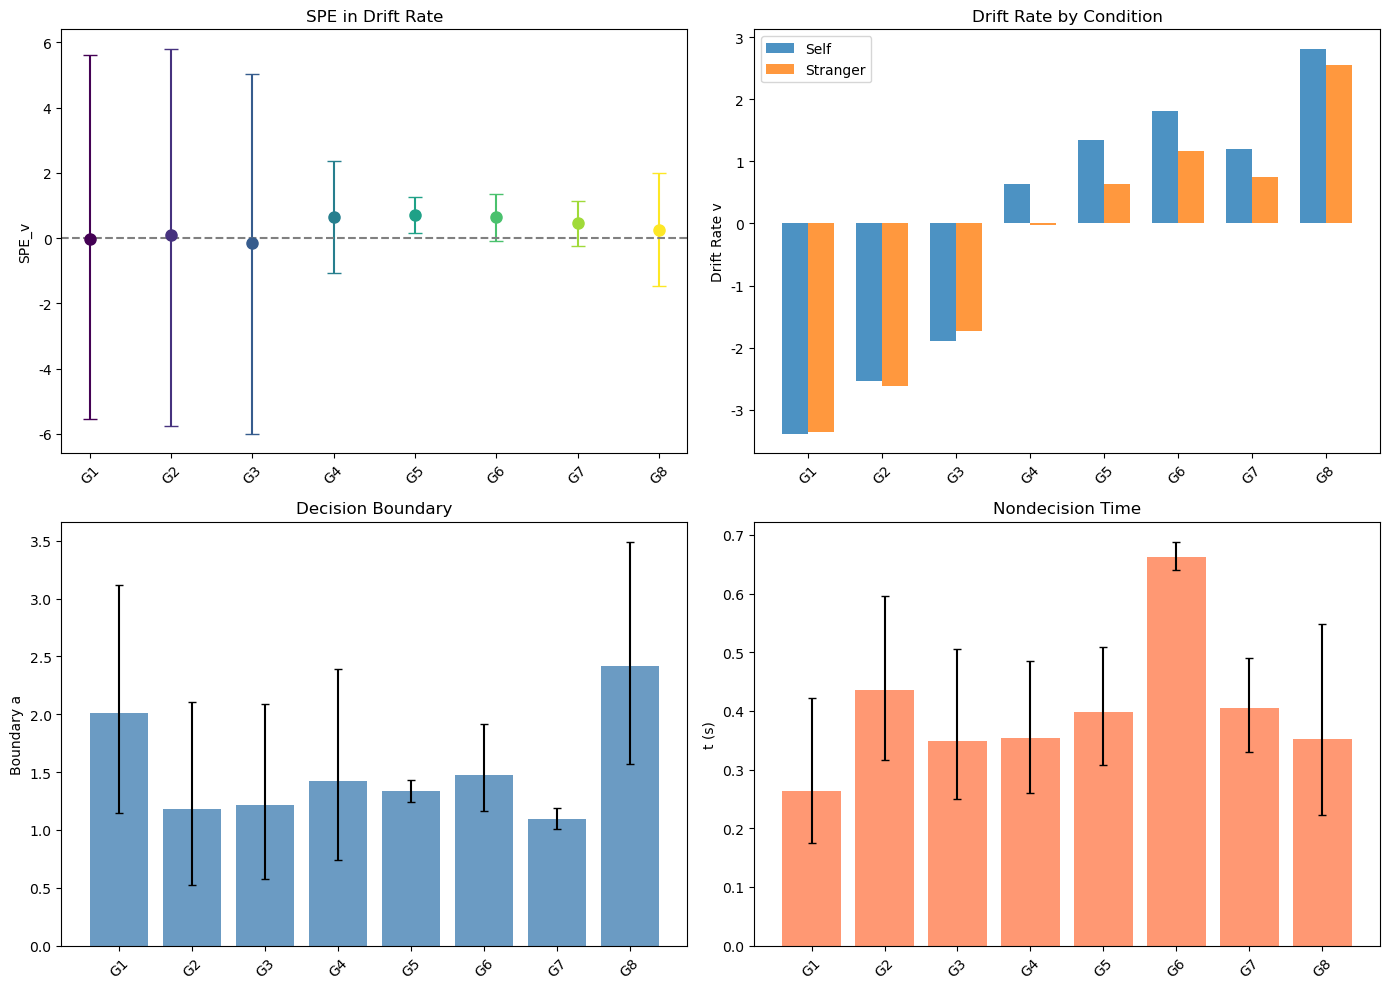


图表已保存到: /home/jovyan/work/3_Figures/HDDM_Results/ddm_params_by_group.png
参数表已保存到: /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/all_groups_ddm_params.csv


In [3]:
# Step 3: 参数提取与可视化
import matplotlib.pyplot as plt
import re

plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

FIG_DIR = BASE_DIR / "3_Figures" / "HDDM_Results"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Step 3: 提取 HDDM 参数后验分布")
print("=" * 60)

stats_files = sorted(OUT_DIR.glob("*_stats.csv"))
if not stats_files:
    print("未找到 stats 文件！请先运行 Step 2。")
else:
    all_params = []
    for stats_path in stats_files:
        fname = stats_path.stem.replace("_stats", "")
        print(f"\n处理: {fname}")

        match = re.search(r"group(\d+)_P(\d+)_T(\d+)_W(\d+)", fname)
        if not match:
            continue
        group_id = int(match.group(1))
        P_val = int(match.group(2))
        T_val = int(match.group(3))
        W_val = int(match.group(4))

        stats = pd.read_csv(stats_path, index_col=0)
        row = {"group_id": group_id, "P": P_val, "T_ms": T_val, "W_ms": W_val, "M_ms": T_val + W_val}

        for stat_key, label in [("v(0)", "v_stranger"), ("v(1)", "v_self"),
                                 ("a", "a"), ("t", "t"), ("z", "z")]:
            if stat_key in stats.index:
                row[f"{label}_mean"] = float(stats.loc[stat_key, "mean"])
                row[f"{label}_std"] = float(stats.loc[stat_key, "std"])
                row[f"{label}_q025"] = float(stats.loc[stat_key, "2.5q"])
                row[f"{label}_q975"] = float(stats.loc[stat_key, "97.5q"])

        if "v_self_mean" in row and "v_stranger_mean" in row:
            row["SPE_v"] = row["v_self_mean"] - row["v_stranger_mean"]
            print(f"  v_self={row['v_self_mean']:.3f}, v_stranger={row['v_stranger_mean']:.3f}, SPE_v={row['SPE_v']:.3f}")

        all_params.append(row)

    df_params = pd.DataFrame(all_params).sort_values("group_id")
    df_params.to_csv(OUT_DIR / "all_groups_ddm_params.csv", index=False)

    disp_cols = ["group_id","P","T_ms","W_ms","v_self_mean","v_stranger_mean","SPE_v","a_mean","t_mean"]
    avail = [c for c in disp_cols if c in df_params.columns]
    print("\n" + "=" * 60)
    print("DDM 参数汇总")
    print("=" * 60)
    print(df_params[avail].round(4).to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax = axes[0, 0]
    if "SPE_v" in df_params.columns:
        valid = df_params.dropna(subset=["SPE_v"])
        colors = plt.cm.viridis(np.linspace(0, 1, len(valid)))
        for i, (_, r) in enumerate(valid.iterrows()):
            lo = r["v_self_mean"] - r["v_self_q025"]
            hi = r["v_self_q975"] - r["v_self_mean"]
            ax.errorbar(i, r["SPE_v"], yerr=[[lo], [hi]], fmt="o", color=colors[i], capsize=5, markersize=8)
        ax.axhline(y=0, color="gray", linestyle="--")
        ax.set_xticks(range(len(valid)))
        ax.set_xticklabels([f"G{r['group_id']:.0f}" for _, r in valid.iterrows()], rotation=45)
        ax.set_ylabel("SPE_v"); ax.set_title("SPE in Drift Rate")

    ax = axes[0, 1]
    if "v_self_mean" in df_params.columns:
        valid = df_params.dropna(subset=["v_self_mean"])
        x = np.arange(len(valid)); w = 0.35
        ax.bar(x-w/2, valid["v_self_mean"], w, label="Self", alpha=0.8)
        ax.bar(x+w/2, valid["v_stranger_mean"], w, label="Stranger", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f"G{r['group_id']:.0f}" for _, r in valid.iterrows()], rotation=45)
        ax.set_ylabel("Drift Rate v"); ax.set_title("Drift Rate by Condition"); ax.legend()

    ax = axes[1, 0]
    if "a_mean" in df_params.columns:
        valid = df_params.dropna(subset=["a_mean"])
        x = np.arange(len(valid))
        ax.bar(x, valid["a_mean"], color="steelblue", alpha=0.8)
        ax.errorbar(x, valid["a_mean"],
                    yerr=[valid["a_mean"]-valid["a_q025"], valid["a_q975"]-valid["a_mean"]],
                    fmt="none", color="black", capsize=3)
        ax.set_xticks(x)
        ax.set_xticklabels([f"G{r['group_id']:.0f}" for _, r in valid.iterrows()], rotation=45)
        ax.set_ylabel("Boundary a"); ax.set_title("Decision Boundary")

    ax = axes[1, 1]
    if "t_mean" in df_params.columns:
        valid = df_params.dropna(subset=["t_mean"])
        x = np.arange(len(valid))
        ax.bar(x, valid["t_mean"], color="coral", alpha=0.8)
        ax.errorbar(x, valid["t_mean"],
                    yerr=[valid["t_mean"]-valid["t_q025"], valid["t_q975"]-valid["t_mean"]],
                    fmt="none", color="black", capsize=3)
        ax.set_xticks(x)
        ax.set_xticklabels([f"G{r['group_id']:.0f}" for _, r in valid.iterrows()], rotation=45)
        ax.set_ylabel("t (s)"); ax.set_title("Nondecision Time")

    plt.tight_layout()
    fig_path = FIG_DIR / "ddm_params_by_group.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"\n图表已保存到: {fig_path}")
    print(f"参数表已保存到: {OUT_DIR / 'all_groups_ddm_params.csv'}")

---
## 输出文件清单

| 文件 | 位置 | 内容 |
|------|------|------|
| `hddm_data_group*.csv` | `2_Data/Real_Data/HDDM_Ready/` | Step 1 预处理后的 HDDM 输入 |
| `*_stats.csv` | `2_Data/Real_Data/HDDM_Traces/` | Step 2 各参数后验摘要 (mean, std, 分位数) |
| `*_traces.pkl` | `2_Data/Real_Data/HDDM_Traces/` | Step 2 完整 MCMC 采样迹线 (pickle) |
| `*_traces.npz` | `2_Data/Real_Data/HDDM_Traces/` | Step 2 完整 MCMC 采样迹线 (numpy) |
| `all_groups_ddm_params.csv` | `2_Data/Real_Data/HDDM_Traces/` | Step 3 所有条件汇总 |
| `ddm_params_by_group.png` | `3_Figures/HDDM_Results/` | Step 3 参数柱状图 |

---
## 注意事项

1. **遗漏试次处理**: 遗漏试次 (omission=1) 的 RT 设为 T+W（截止时间），response=0，作为截尾数据参与拟合
2. **Group 1 高遗漏率**: W=300ms 条件下遗漏率约 72%，DDM 参数估计可能不稳定，建议后续分析时关注其后验分布宽度
3. **数据路径**: 所有输出直接写入项目根目录的 `2_Data/` 和 `3_Figures/` 下，因为 Docker 挂载了整个项目根目录
4. **重新拟合**: 如需重新拟合，直接重新运行 Step 2 单元格即可（会覆盖已有文件）